# 01 — Profiling one month of NYC school bus incidents

**Goal:** look at the real data *before* writing any validation rules. Every rule in `src/validate/` should trace back to something observed here.

**Month profiled:** October 2025 — the first full month of the 2025-26 school year (September starts mid-month).

**Sources touched:** S1 incidents (API), S2 routes, S3 sites, S4 weather. Raw pulls are saved to `data/raw/profiling/` (not committed).

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
from src.config import load_config, month_bounds, school_year_for_month

cfg = load_config()
MONTH = "2025-10"
START, END = month_bounds(MONTH)
SCHOOL_YEAR = school_year_for_month(MONTH)
RAW = REPO / "data" / "raw" / "profiling" / MONTH
RAW.mkdir(parents=True, exist_ok=True)
NYC = "https://data.cityofnewyork.us/resource/"

def soql(dataset_id, **params):
    r = requests.get(f"{NYC}{dataset_id}.json", params=params, timeout=cfg["http"]["timeout_seconds"])
    r.raise_for_status()
    return r.json()

def hbar(series, title, fmt="{:,.0f}"):
    ax = series.sort_values().plot.barh(color="#2a78d6", width=0.6, figsize=(7, 0.35 * len(series) + 1))
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_ylabel("")
    ax.grid(axis="x", color="#e5e5e2", linewidth=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    for p in ax.patches:
        ax.annotate(fmt.format(p.get_width()), (p.get_width(), p.get_y() + p.get_height() / 2),
                    xytext=(4, 0), textcoords="offset points", va="center", fontsize=9, color="#52514e")
    plt.show()

pd.set_option("display.max_colwidth", 80)
print(MONTH, START, END, SCHOOL_YEAR)

Matplotlib is building the font cache; this may take a moment.


2025-10 2025-10-01 2025-10-31 2025-2026


## 1. Is the pull complete?

Ask the API how many rows match **first**, then page through and check we received exactly that many, with no duplicate IDs and nothing outside the month.

In [2]:
where = f"occurred_on between '{START}T00:00:00' and '{END}T23:59:59'"
expected = int(soql(cfg["sources"]["incidents"]["dataset_id"], **{"$select": "count(*)", "$where": where})[0]["count"])

page_size = cfg["sources"]["incidents"]["page_size"]
pages, offset = [], 0
while True:
    page = soql(cfg["sources"]["incidents"]["dataset_id"],
                **{"$where": where, "$order": "busbreakdown_id", "$limit": page_size, "$offset": offset})
    (RAW / f"incidents_page_{len(pages):03d}.json").write_text(json.dumps(page))
    pages.append(page)
    if len(page) < page_size:
        break
    offset += page_size

df = pd.DataFrame([row for page in pages for row in page])
for c in ["occurred_on", "created_on", "informed_on", "last_updated_on"]:
    df[c] = pd.to_datetime(df[c])

checks = {
    "expected rows (count(*))": expected,
    "received rows": len(df),
    "pages": len(pages),
    "duplicate busbreakdown_id": int(df["busbreakdown_id"].duplicated().sum()),
    "min occurred_on": df["occurred_on"].min(),
    "max occurred_on": df["occurred_on"].max(),
}
pd.Series(checks, name="value").to_frame()

,value
expected rows (count(*)),9176
received rows,9176
pages,1
duplicate busbreakdown_id,0
min occurred_on,2025-10-01 01:30:00
max occurred_on,2025-10-31 15:52:00


## 2. Shape and missing values

In [3]:
print(df.shape)
nulls = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
nulls[nulls > 0].to_frame("% null")

(9176, 21)


,% null
incident_number,100.0
how_long_delayed,5.2


- `incident_number` is **100% empty** — useless, will not be modelled.
- `how_long_delayed` has gaps — section 4 shows these are exactly the *Breakdown* rows.
- Everything else is fully populated, which is suspicious in itself for self-reported data (the form probably forces an answer).

In [4]:
for col in ["breakdown_or_running_late", "run_type", "school_age_or_prek", "reason", "boro"]:
    print(f"--- {col}")
    print(df[col].value_counts(dropna=False).to_string(), "\n")

--- breakdown_or_running_late
breakdown_or_running_late
Running Late    8697
Breakdown        479 

--- run_type
run_type
Special Ed AM Run        6124
Special Ed PM Run        1108
General Ed AM Run        1031
Pre-K/EI                  617
General Ed PM Run         240
Special Ed Field Trip      29
General Ed Field Trip      27 

--- school_age_or_prek
school_age_or_prek
School-Age    8559
Pre-K          617 

--- reason
reason
Heavy Traffic                  5988
Other                          1432
Problem Run                    1123
Mechanical Problem              306
Late return from Field Trip      80
Won`t Start                      71
Weather Conditions               60
Flat Tire                        40
Accident                         39
Delayed by School                37 

--- boro
boro
Brooklyn           2817
Bronx              2131
Queens             1747
Nassau County      1250
Manhattan           611
Staten Island       427
Westchester          95
New Jersey           5

- **Special Ed runs dominate** incidents (~80% of the month).
- `reason = "Other"` is a large bucket — limits root-cause analysis.
- `boro` includes **Nassau County, Westchester, New Jersey, Connecticut** and "All Boroughs": students are bussed to out-of-city placements. Borough is *not* a clean NYC dimension — location should come from the sites table instead.

## 3. Timestamps: occurred → created → informed

In [5]:
lag_min = (df["created_on"] - df["occurred_on"]).dt.total_seconds() / 60
ts = {
    "created before occurred (time travel)": int((df["created_on"] < df["occurred_on"]).sum()),
    "logged > 24h after occurring": int((lag_min > 24 * 60).sum()),
    "informed_on == created_on (share)": round((df["informed_on"] == df["created_on"]).mean(), 4),
    "occurred_on has seconds != 0 (share)": round((df["occurred_on"].dt.second != 0).mean(), 4),
}
display(pd.Series(ts, name="value").to_frame())
lag_min.describe(percentiles=[.25, .5, .75, .9, .99]).round(1).to_frame("logging lag (min)")

,value
created before occurred (time travel),4.0
logged > 24h after occurring,10.0
informed_on == created_on (share),1.0
occurred_on has seconds != 0 (share),0.0


,logging lag (min)
count,9176.0
mean,44.1
std,681.8
min,-453.0
25%,1.0
50%,3.0
75%,15.0
90%,67.0
99%,219.2
max,26478.0


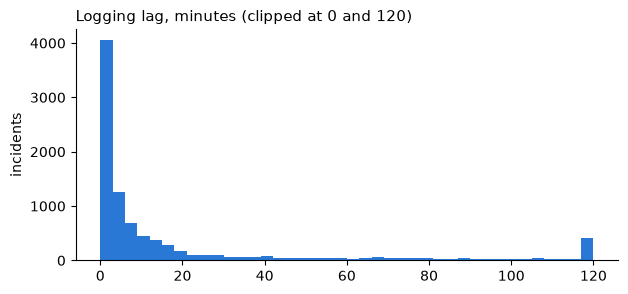

In [6]:
ax = lag_min.clip(0, 120).plot.hist(bins=40, color="#2a78d6", figsize=(7, 3))
ax.set_title("Logging lag, minutes (clipped at 0 and 120)", loc="left", fontsize=11)
ax.set_ylabel("incidents")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

**Key finding — `informed_on` is not a real notification time.** It equals `created_on` in every row, so the system stamps it automatically when the report is saved. There is therefore **no timestamp for when parents or schools were actually told**.

*Plan change:* drop any "notification lag" metric. Notification can only be measured through the Yes/No flags. The logging lag (`created_on − occurred_on`) is still valid: most reports are entered within minutes, with a long tail and a handful of negative (time-travel) rows.

## 4. The delay field

The initial plan expected messy free text (`"30MINS"`, `"30 MINTUES"` ...). Check what this month actually contains, and how the field looked in earlier school years.

In [7]:
print(df.groupby("breakdown_or_running_late")["how_long_delayed"].apply(lambda s: s.isna().mean()).rename("share missing"))
print()
print(df["how_long_delayed"].value_counts(dropna=False).to_string())

breakdown_or_running_late
Breakdown       1.0
Running Late    0.0
Name: share missing, dtype: float64

how_long_delayed
16-30 Min    3803
61-90 Min    1953
0-15 Min     1242
31-45 Min    1067
46-60 Min     632
NaN           479


In [8]:
hist = pd.DataFrame(soql(cfg["sources"]["incidents"]["dataset_id"], **{
    "$select": "school_year, how_long_delayed, count(*) as n",
    "$where": "school_year in ('2016-2017','2018-2019','2020-2021','2021-2022','2022-2023','2023-2024','2024-2025','2025-2026')",
    "$group": "school_year, how_long_delayed", "$limit": 50000}))
hist.groupby("school_year")["how_long_delayed"].nunique().to_frame("distinct delay values")

,distinct delay values
school_year,
2016-2017,1205
2018-2019,5
2020-2021,6
2021-2022,5
2022-2023,5
2023-2024,5
2024-2025,5
2025-2026,5


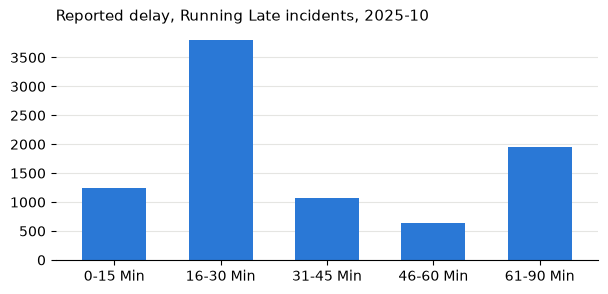

In [9]:
order = ["0-15 Min", "16-30 Min", "31-45 Min", "46-60 Min", "61-90 Min"]
counts = df["how_long_delayed"].value_counts().reindex(order)
ax = counts.plot.bar(color="#2a78d6", width=0.6, figsize=(7, 3), rot=0)
ax.set_title(f"Reported delay, Running Late incidents, {MONTH}", loc="left", fontsize=11)
ax.set_xlabel("")
ax.grid(axis="y", color="#e5e5e2", linewidth=0.8); ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
plt.show()

**Finding — the free-text problem is historical.** 2016-17 had **1,205 distinct spellings**; from 2018-19 onward there are exactly **5 dropdown buckets** (2020-21 shows one stray extra value). For our scope (2024-25 onward) the parser only needs to map 5 ranges — but it should still handle legacy free text in case older months are run.

**New problem found — the top bucket is open-ended.** "61-90 Min" is the highest option, so a 2-hour delay is recorded as 61-90. Longer delays are invisible (*censored*). Any student-minutes figure is therefore a **lower bound**, and this goes in the Limitations.

**Breakdowns never have a delay value** — they must be excluded from delay metrics, not treated as 0.

## 5. Notification flags (the KPI)

In [10]:
flags = ["has_contractor_notified_parents", "has_contractor_notified_schools", "have_you_alerted_opt"]
display(pd.DataFrame({f: df[f].value_counts(dropna=False) for f in flags}).T)
by_run = (df["has_contractor_notified_parents"].eq("Yes")
          .groupby(df["run_type"]).agg(["mean", "size"])
          .rename(columns={"mean": "parents notified (claimed)", "size": "incidents"}))
by_run.sort_values("incidents", ascending=False).style.format({"parents notified (claimed)": "{:.1%}"})

,No,Yes
has_contractor_notified_parents,4794,4382
has_contractor_notified_schools,3559,5617
have_you_alerted_opt,8221,955


,parents notified (claimed),incidents
run_type,,
Special Ed AM Run,50.5%,6124
Special Ed PM Run,33.6%,1108
General Ed AM Run,33.0%,1031
Pre-K/EI,89.3%,617
General Ed PM Run,5.4%,240
Special Ed Field Trip,31.0%,29
General Ed Field Trip,7.4%,27


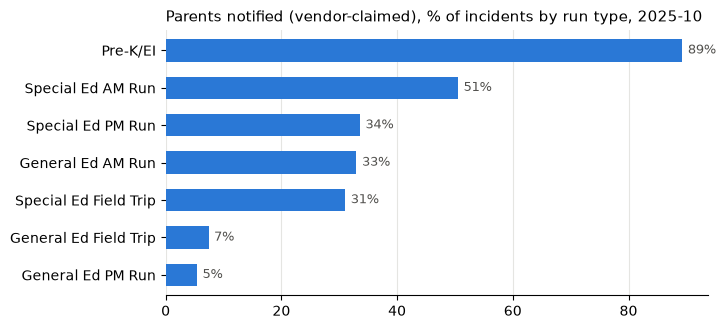

In [11]:
hbar(by_run["parents notified (claimed)"] * 100, f"Parents notified (vendor-claimed), % of incidents by run type, {MONTH}", fmt="{:.0f}%")

- Parents were reported as notified in **fewer than half** of this month's incidents.
- The spread by run type is huge: **Pre-K/EI is near 90%**, while **General Ed PM runs are in single digits**. That's a concrete, actionable split for OPT.
- OPT itself is alerted in only ~1 in 10 incidents.
- All three flags are always Yes/No (no blanks) in this month, but they remain **vendor claims** with no timestamp behind them (section 3).

## 6. Students on the bus

In [12]:
students = pd.to_numeric(df["number_of_students_on_the_bus"], errors="coerce")
display(students.describe().round(1).to_frame("students"))
lo, hi = cfg["validation"]["students_on_bus_range"]
df.loc[students > hi, ["busbreakdown_id", "run_type", "number_of_students_on_the_bus", "bus_company_name"]]

,students
count,9176.0
mean,3.1
std,97.6
min,0.0
25%,0.0
50%,0.0
75%,2.0
max,9056.0


,busbreakdown_id,run_type,number_of_students_on_the_bus,bus_company_name
2446,2020957,General Ed AM Run,222,EMPIRE STATE BUS CORP.
2863,2021375,Special Ed AM Run,9056,PIONEER TRANSPORTATION CORP
3186,2021698,Special Ed AM Run,1427,HOYT TRANSPORTATION CORP.
4371,2022884,Special Ed AM Run,110,CAREFUL BUS
6261,2024774,Special Ed AM Run,1801,NYC SCHOOL BUS UMBRELLA SERVICES


- The median is **0**: most incidents are reported before any student is picked up (AM runs running late to the first stop). Student-minutes will be concentrated in a minority of incidents.
- A few values exceed any bus capacity (the maximum is in the thousands) — data-entry errors → rule V10 flags them rather than capping them.

## 7. Join: incidents → Routes (who is the vendor?)

The initial plan gets the vendor from `route_number` via the Routes table. Check uniqueness and match rate.

In [13]:
routes = pd.DataFrame(soql(cfg["sources"]["routes"]["dataset_id"], school_year=SCHOOL_YEAR, **{"$limit": 50000}))
(RAW / "routes.json").write_text(routes.to_json(orient="records"))
print("routes rows:", len(routes), "| duplicate route_number:", routes["route_number"].duplicated().sum(),
      "| routes with >1 vendor:", (routes.groupby("route_number")["vendor_code"].nunique() > 1).sum(),
      "| vendors:", routes["vendor_code"].nunique())
matched = df["route_number"].isin(routes["route_number"])
print(f"incident routes found in Routes table: {matched.mean():.1%}")
matched.groupby(df["run_type"]).mean().to_frame("share matched").style.format("{:.1%}")

routes rows: 10429 | duplicate route_number: 0 | routes with >1 vendor: 0 | vendors: 38
incident routes found in Routes table: 93.3%


,share matched
run_type,
General Ed AM Run,100.0%
General Ed Field Trip,100.0%
General Ed PM Run,100.0%
Pre-K/EI,0.5%
Special Ed AM Run,100.0%
Special Ed Field Trip,100.0%
Special Ed PM Run,100.0%


In [14]:
j = df[matched].merge(routes[["route_number", "vendor_code", "vendor_name"]], on="route_number")
print(f"bus_company_name == Routes vendor_name: {(j['bus_company_name'] == j['vendor_name']).mean():.2%}")
j.loc[j["bus_company_name"] != j["vendor_name"], ["route_number", "bus_company_name", "vendor_name"]].drop_duplicates()

bus_company_name == Routes vendor_name: 99.96%


,route_number,bus_company_name,vendor_name
117,K257,L & M BUS CORP.,PRIDE TRANSPORTATION (SCH AGE)
4415,Q620,SMART PICK INC,PRIDE TRANSPORTATION (SCH AGE)
4417,Q368,SMART PICK INC,PRIDE TRANSPORTATION (SCH AGE)


**Findings:**
- Within a school year each route belongs to exactly one vendor — the route key is clean.
- **All school-age runs match; Pre-K/EI runs almost never do.** The Routes dataset excludes Pre-K curb-to-curb service (as its own documentation says).
- In current data the incident's `bus_company_name` agrees with the Routes vendor almost always. (The truncated names seen in 2016 records don't occur here.) The few disagreements look like subcontracting or mid-year route transfers — worth listing, not "fixing".

**Judgement call:** vendor = Routes vendor when the route matches (authoritative contract data); otherwise fall back to `bus_company_name`, and record which method was used (`vendor_source = routes | reported_name`). Pre-K incidents stay in the analysis but are clearly labelled.

## 8. Reference data coverage by school year

In [15]:
cov = pd.DataFrame({
    "routes": {r["school_year"]: int(r["n"]) for r in soql(cfg["sources"]["routes"]["dataset_id"], **{"$select": "school_year, count(*) as n", "$group": "school_year"})},
    "sites": {r["school_year"]: int(r["n"]) for r in soql(cfg["sources"]["sites"]["dataset_id"], **{"$select": "school_year, count(*) as n", "$group": "school_year"})},
}).sort_index()
cov

,routes,sites
2013-2014,3,NaN
2014-2015,18,NaN
2015-2016,9951,4485.0
2016-2017,10620,4551.0
2017-2018,10856,4641.0
2018-2019,10861,4571.0
2019-2020,11113,4643.0
2020-2021,18,NaN
2024-2025,10278,6393.0
2025-2026,10429,6499.0


**Finding — the reference tables have holes.** There is (almost) nothing for **2020-21 to 2023-24**, and nothing yet for **2026-27**. Incidents for those years cannot be attributed to vendors via routes.

*Plan change:* the pipeline's scope is **2024-25 and 2025-26**, where both reference tables exist. For a month whose school year has no Routes data, the pipeline must say so loudly (fallback / degraded run) rather than silently producing vendor metrics with an empty join.

## 9. Join: incidents → Sites (which schools?)

In [16]:
sites = pd.DataFrame(soql(cfg["sources"]["sites"]["dataset_id"], school_year=SCHOOL_YEAR, **{"$limit": 50000}))
(RAW / "sites.json").write_text(sites.to_json(orient="records"))
codes = df["schools_serviced"].str.split(",").explode().str.strip()
print("sites rows:", len(sites), "| duplicate opt_code:", sites["opt_code"].duplicated().sum())
print(f"incidents serving >1 school: {df['schools_serviced'].str.contains(',').mean():.1%}")
print(f"incident-school pairs: {len(codes):,} | matched to a site: {codes.isin(sites['opt_code']).mean():.1%}")

sites rows: 6499 | duplicate opt_code: 0
incidents serving >1 school: 70.1%
incident-school pairs: 22,712 | matched to a site: 100.0%


- Most incidents serve **several schools** — confirming the need for a bridge table (joining directly would multiply incident counts).
- Site codes match the Sites table essentially perfectly for this year.

## 10. Weather — are "Weather Conditions" reasons plausible?

In [17]:
w = requests.get(cfg["sources"]["weather"]["api_url"], timeout=cfg["http"]["timeout_seconds"], params={
    "latitude": cfg["sources"]["weather"]["latitude"], "longitude": cfg["sources"]["weather"]["longitude"],
    "start_date": str(START), "end_date": str(END), "timezone": cfg["sources"]["weather"]["timezone"],
    "hourly": ",".join(cfg["sources"]["weather"]["hourly"])}).json()
(RAW / "weather.json").write_text(json.dumps(w))
wh = pd.DataFrame(w["hourly"])
print(f"hours received: {len(wh)} | expected: {24 * END.day}")
daily = wh.assign(date=wh["time"].str[:10]).groupby("date")[["precipitation", "snowfall"]].sum()
wx = df[df["reason"] == "Weather Conditions"].assign(date=lambda d: d["occurred_on"].dt.strftime("%Y-%m-%d"))
wx.groupby("date").size().to_frame("weather-reason incidents").join(daily)

hours received: 744 | expected: 744


,weather-reason incidents,precipitation,snowfall
date,,,
2025-10-08,10,5.4,0.0
2025-10-14,1,0.1,0.0
2025-10-20,2,10.2,0.0
2025-10-22,8,1.5,0.0
2025-10-30,39,44.4,0.0


- Hour count matches the calendar (completeness check works for this source).
- In this month, "Weather Conditions" incidents cluster on genuinely wet days (the largest cluster is on the wettest day). One incident falls on a day with almost no rain. Rule V12 is still worth having — but it should use a small threshold rather than exactly 0 mm, and it's a **warning**, not proof of a false excuse.

## 11. Summary — what profiling changed

| # | Observation | Consequence |
|---|---|---|
| 1 | `informed_on` always equals `created_on` | No real notification time. Drop any notification-lag metric; KPI relies on Yes/No flags, labelled *vendor-claimed* |
| 2 | Delay is a 5-bucket dropdown since 2018-19; free text (1,205 spellings) only in older years | Parser maps 5 ranges (keeps legacy free-text handling as a fallback) |
| 3 | Top delay bucket is "61-90 Min" | Long delays are censored → student-minutes is a **lower bound** (Limitation) |
| 4 | Breakdowns never have a delay | Excluded from delay metrics, never treated as 0 |
| 5 | Parent notification < 50% overall; ~90% Pre-K vs single digits for Gen Ed PM | Split KPI by run type — the headline finding |
| 6 | Median students on bus = 0; a few impossible counts | Rule V10 (warning); student-minutes concentrated in few incidents |
| 7 | Pre-K routes are not in the Routes table | Vendor fallback to reported name, with `vendor_source` column |
| 8 | Routes/Sites missing 2020-21 → 2023-24 and 2026-27 | Scope = 2024-25 and 2025-26; pipeline flags years without reference data |
| 9 | Most incidents serve multiple schools | Bridge table confirmed |
| 10 | `boro` includes places outside NYC | Don't use `boro` as a location dimension; use Sites |
| 11 | Small number of time-travel and >24h-lag reports | Rules V02 (critical) and V03 (warning) confirmed |
| 12 | `incident_number` 100% empty | Not modelled |
| 13 | Weather reasons mostly match wet days | V12 kept as a warning with a small precipitation threshold |